In [1]:
!pip install tf-keras -q
!pip install -q transformers==4.38.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [2]:
# import os
# os.kill(os.getpid(), 9)

In [3]:
import transformers
print(transformers.__version__)

# See if TF classes exist
print(hasattr(transformers, 'TFBertForSequenceClassification'))

4.38.2


2026-05-08 14:34:23.522315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778250863.716005      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778250863.772255      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778250864.218955      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778250864.218995      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778250864.219003      23 computation_placer.cc:177] computation placer alr

True


In [4]:

import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout ,SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer
from sklearn.utils import class_weight
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report ,confusion_matrix
from transformers import TFBertForSequenceClassification
from transformers import BertTokenizer
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tf_keras
import pickle
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/kaggle/input/private-dataset/Model Dataset.csv") 
df.dropna(inplace =True)
df.drop_duplicates(inplace=True)
df

,content,CleanComment,label
0,Please let me hide my reels session,please let me hide my reel session,0
1,good,good,1
2,love you mamah,love you mamah,1
3,ads and AI content are out of hand,ads and ai content be out of hand,0
4,Nice apps,nice apps,1
...,...,...,...
510831,Tha price is right all the time,tha price be right all the time,1
510832,ItsMee..t,itsmee .. t,1
510833,Does everything needed,do everything need,1
510834,Klein g po,klein g po,1


In [6]:

max_words = df["CleanComment"].str.split().str.len().median()
print(f"Longest comment in the dataset is {max_words} words long.")

Longest comment in the dataset is 25.0 words long.


In [7]:
X = df["CleanComment"]
Y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [8]:
lengths = df["CleanComment"].str.split().str.len()
VOCAB_SIZE = 20000
MAX_LEN = int(lengths.quantile(0.95))
NUM_CLASSES = 2

In [9]:
# Load the pre-trained BERT tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Tokenize the text (this automatically handles padding and truncation)
# We will use the MAX_LEN you calculated earlier
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [10]:
# BERT is memory-heavy, so use a smaller batch size like 16 or 32 instead of 128
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings),y_train.values)).shuffle(len(X_train)).batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings),y_test.values)).batch(BATCH_SIZE)

I0000 00:00:1778251028.608154      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778251028.611258      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y_train),y=y_train.values)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(1.0439550668365987), 1: np.float64(0.9595967851791309)}


In [12]:
optimizer = tf_keras.optimizers.AdamW(learning_rate=2e-5, weight_decay=0.01)

model = TFRobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=NUM_CLASSES)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compile the model
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [13]:
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath='best_model_weights.h5', 
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True, 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stopping, checkpoint_callback]

In [14]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    batch_size=128,
    epochs=3,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/3


I0000 00:00:1778251136.400299      85 service.cc:152] XLA service 0x7bcd87029d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778251136.400338      85 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778251136.400342      85 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778251136.493236      85 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778251136.671429      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22014/22014 [==============================] - ETA: 0s - loss: 0.2438 - accuracy: 0.9051
Epoch 1: val_loss improved from inf to 0.22740, saving model to best_model_weights.h5
22014/22014 [==============================] - 9032s 408ms/step - loss: 0.2438 - accuracy: 0.9051 - val_loss: 0.2274 - val_accuracy: 0.9157
Epoch 2/3
22014/22014 [==============================] - ETA: 0s - loss: 0.2111 - accuracy: 0.9192
Epoch 2: val_loss improved from 0.22740 to 0.21457, saving model to best_model_weights.h5
22014/22014 [==============================] - 8911s 405ms/step - loss: 0.2111 - accuracy: 0.9192 - val_loss: 0.2146 - val_accuracy: 0.9166
Epoch 3/3
22014/22014 [==============================] - ETA: 0s - loss: 0.1903 - accuracy: 0.9278
Epoch 3: val_loss did not improve from 0.21457
22014/22014 [==============================] - 8884s 404ms/step - loss: 0.1903 - accuracy: 0.9278 - val_loss: 0.2173 - val_accuracy: 0.9184
Restoring model weights from the end of the best epoch: 2.


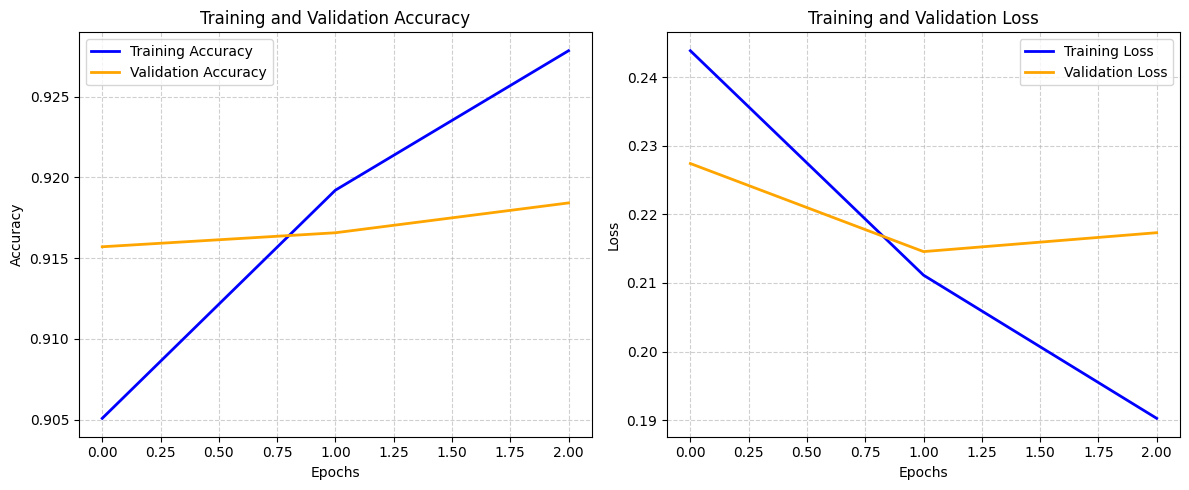

In [15]:
plt.figure(figsize=(12, 5))

#! Plot 1: Accuracy 
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


#! Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"Validation accuracy of final model: {acc:.4f}")

Validation accuracy of final model: 0.9166


In [17]:
predictions = model.predict(test_dataset)
logits = predictions.logits
y_pred_labels = np.argmax(logits, axis=1)

9435/9435 [==============================] - 1085s 115ms/step


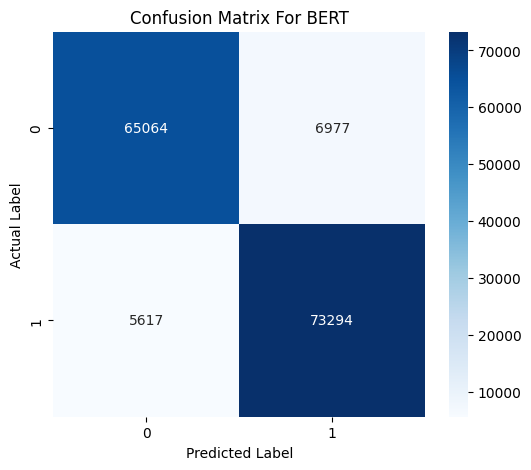

In [18]:
conf = confusion_matrix(y_true=y_test, y_pred=y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues") 
plt.title("Confusion Matrix For BERT")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

In [19]:
print("Classification Report:")
print(classification_report(y_test, y_pred_labels, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     72041
           1       0.91      0.93      0.92     78911

    accuracy                           0.92    150952
   macro avg       0.92      0.92      0.92    150952
weighted avg       0.92      0.92      0.92    150952



In [20]:
import os

model_path = './sentiment_roberta_model'
if not os.path.exists(model_path):
    os.makedirs(model_path)

model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model and tokenizer saved successfully to {model_path}")

Model and tokenizer saved successfully to ./sentiment_roberta_model
